# Deep learning for genomics — a representative method, end to end

**Review paper (Paper #5):** Eraslan, Avsec, Gagneur & Theis, *Nature Reviews Genetics* 2019 —
["Deep learning: new computational modelling techniques for genomics"](https://www.nature.com/articles/s41576-019-0122-6).

**Assigned to:** Aditya · *Team 1 — Variant Prioritization*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/adtyapnda/variant-prioritization-team1/blob/main/papers/05-deep-learning-genomics-review/deep_learning_genomics_review_demo.ipynb)

---

This paper is a **review**: it surveys deep-learning methods across genomics rather than
shipping a single tool. So, following this folder's plan (*"demo one representative method it
covers"*), this notebook walks through **one representative method end to end** and ties it to
our team's goal — **variant prioritization**.

**What we build**

1. **Represent DNA as a one-hot tensor** — the sequence "feature extraction" step the review
   describes for sequence models.
2. A small **convolutional neural network (CNN)** — the architecture family behind DeepBind,
   Basset, Basenji and **Akita (Paper #4)** — trained to recognise a transcription-factor
   binding motif.
3. **In-silico saturation mutagenesis (ISM)** — the model-interpretation technique the review
   highlights — to score the effect of *every possible single-nucleotide variant* and **rank
   variants by predicted impact**. This is exactly the mechanism Akita uses to prioritise
   structural variants and eQTLs.

Everything is **self-contained and reproducible** (synthetic data, fixed random seed): it runs
in seconds on a CPU with no downloads, in Colab or locally.

## 0. Setup

Only standard scientific-Python + PyTorch packages, all pre-installed on Colab.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.12.0+cpu | device: cpu


## 1. Representing DNA as a one-hot tensor

Neural networks need numbers, not letters. The review's first practical step for sequence
models is to encode a DNA string of length *L* as a **4 x L** binary matrix — one row per base
(A, C, G, T). This is the input format used by essentially every sequence CNN in genomics,
Akita included.

In [2]:
BASES = "ACGT"
BASE_TO_IDX = {b: i for i, b in enumerate(BASES)}

def one_hot(seq):
    """DNA string -> (4, L) float array; rows are A, C, G, T."""
    m = np.zeros((4, len(seq)), dtype=np.float32)
    for j, b in enumerate(seq):
        m[BASE_TO_IDX[b], j] = 1.0
    return m

demo = "ACGTAC"
print("sequence:", demo)
print("one-hot (rows A, C, G, T):")
print(one_hot(demo).astype(int))

sequence: ACGTAC
one-hot (rows A, C, G, T):
[[1 0 0 0 1 0]
 [0 1 0 0 0 1]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]]


## 2. A synthetic transcription-factor binding dataset

A canonical supervised task in the review is **predicting whether a DNA region is bound by a
transcription factor**. To keep the notebook self-contained, we generate a labelled dataset
instead of downloading ChIP-seq data:

- **Positives** — random background sequence with a **CTCF-like motif planted at a random
  position**. CTCF is the very motif Akita relies on for 3D-folding predictions, so this ties
  directly into Paper #4.
- **Negatives** — pure random background, no motif.

The model must learn to detect the motif *wherever* it appears.

In [3]:
SEQ_LEN     = 200
MOTIF       = "CCGCGNGGNGGCAG"   # simplified CTCF-like consensus (N = any base)
N_PER_CLASS = 2000

def random_seq(L):
    return "".join(np.random.choice(list(BASES), size=L))

def instantiate_motif(motif):
    return "".join(np.random.choice(list(BASES)) if b == "N" else b for b in motif)

def make_dataset(n_per_class, seq_len, motif):
    X, y, planted = [], [], []
    for _ in range(n_per_class):                       # positives
        s = list(random_seq(seq_len))
        m = instantiate_motif(motif)
        pos = np.random.randint(0, seq_len - len(m))
        s[pos:pos + len(m)] = list(m)
        X.append("".join(s)); y.append(1); planted.append(pos)
    for _ in range(n_per_class):                       # negatives
        X.append(random_seq(seq_len)); y.append(0); planted.append(-1)
    return X, np.array(y, dtype=np.float32), np.array(planted)

seqs, labels, planted_pos = make_dataset(N_PER_CLASS, SEQ_LEN, MOTIF)
X = np.stack([one_hot(s) for s in seqs])               # (N, 4, L)
print("X shape:", X.shape,
      "| positives:", int(labels.sum()),
      "| negatives:", int((labels == 0).sum()))

X shape: (4000, 4, 200) | positives: 2000 | negatives: 2000


In [4]:
# shuffle, then 80/20 train/test split
perm = np.random.permutation(len(labels))
Xs, ys = X[perm], labels[perm]
n_train = int(0.8 * len(ys))
Xtr, Xte = Xs[:n_train], Xs[n_train:]
ytr, yte = ys[:n_train], ys[n_train:]

Xtr_t = torch.tensor(Xtr); ytr_t = torch.tensor(ytr).unsqueeze(1)
Xte_t = torch.tensor(Xte); yte_t = torch.tensor(yte).unsqueeze(1)
print("train:", Xtr.shape, "| test:", Xte.shape)

train: (3200, 4, 200) | test: (800, 4, 200)


## 3. A small convolutional neural network

The review explains why CNNs dominate sequence genomics: the **convolutional filters act as
learnable motif scanners**, and **global max-pooling** makes the prediction invariant to *where*
the motif sits in the window. This is the DeepBind/Basset design, and the same building block
Akita stacks to reach megabase scale.

- `Conv1d(4 -> F)` : F filters slide across the sequence, each scoring a short motif.
- `ReLU`            : keep positive matches.
- global max-pool  : "is the motif present anywhere?"
- `Linear -> 1`    : combine filter evidence into a binding logit.

In [5]:
class DNACNN(nn.Module):
    """DeepBind/Basset-style CNN: conv motif scanners -> global max-pool -> dense."""
    def __init__(self, n_filters=16, kernel_size=15):
        super().__init__()
        self.conv = nn.Conv1d(4, n_filters, kernel_size)
        self.act  = nn.ReLU()
        self.fc   = nn.Linear(n_filters, 1)

    def forward(self, x):
        x = self.act(self.conv(x))        # (N, F, L')
        x = torch.max(x, dim=2).values    # global max-pool -> (N, F)
        return self.fc(x)                 # logit

model = DNACNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print("trainable parameters:", n_params)

DNACNN(
  (conv): Conv1d(4, 16, kernel_size=(15,), stride=(1,))
  (act): ReLU()
  (fc): Linear(in_features=16, out_features=1, bias=True)
)
trainable parameters: 993


## 4. Train

Binary cross-entropy + Adam. A handful of epochs is plenty on this task.

In [6]:
loss_fn = nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS, BATCH = 15, 128

Xtr_d, ytr_d = Xtr_t.to(DEVICE), ytr_t.to(DEVICE)
history = []
for epoch in range(EPOCHS):
    model.train()
    order = torch.randperm(len(Xtr_d))
    running = 0.0
    for i in range(0, len(Xtr_d), BATCH):
        idx = order[i:i + BATCH]
        opt.zero_grad()
        loss = loss_fn(model(Xtr_d[idx]), ytr_d[idx])
        loss.backward(); opt.step()
        running += loss.item() * len(idx)
    running /= len(Xtr_d)
    history.append(running)
    print(f"epoch {epoch + 1:2d}/{EPOCHS}  train loss {running:.4f}")

epoch  1/15  train loss 0.6932
epoch  2/15  train loss 0.6793
epoch  3/15  train loss 0.6572


epoch  4/15  train loss 0.6282
epoch  5/15  train loss 0.5891


epoch  6/15  train loss 0.5400
epoch  7/15  train loss 0.4842


epoch  8/15  train loss 0.4248
epoch  9/15  train loss 0.3656
epoch 10/15  train loss 0.3095


epoch 11/15  train loss 0.2615
epoch 12/15  train loss 0.2205
epoch 13/15  train loss 0.1878


epoch 14/15  train loss 0.1598
epoch 15/15  train loss 0.1377


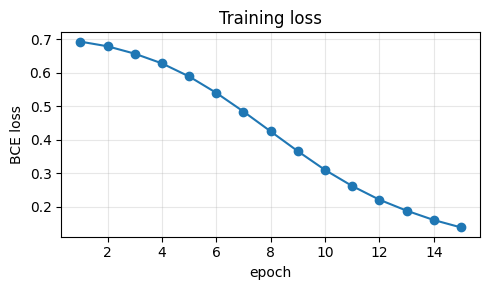

In [7]:
plt.figure(figsize=(5, 3))
plt.plot(range(1, EPOCHS + 1), history, marker="o")
plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.title("Training loss")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 5. Evaluate

Accuracy and ROC-AUC on the held-out test set.

test accuracy: 0.993
test ROC-AUC : 1.000


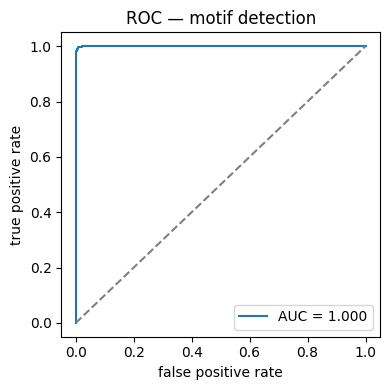

In [8]:
model.eval()
with torch.no_grad():
    logits = model(Xte_t.to(DEVICE)).cpu().numpy().ravel()
probs = 1.0 / (1.0 + np.exp(-logits))
auc = roc_auc_score(yte, probs)
acc = ((probs > 0.5).astype(int) == yte).mean()
print(f"test accuracy: {acc:.3f}")
print(f"test ROC-AUC : {auc:.3f}")

fpr, tpr, _ = roc_curve(yte, probs)
plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("ROC — motif detection"); plt.legend(); plt.tight_layout(); plt.show()

## 6. In-silico saturation mutagenesis -> variant prioritization

This is the payoff, and the review's key **interpretation** technique. For one sequence we
substitute **every position with every alternative base**, re-run the model, and record the
change in predicted score:

$$\Delta_{j,b} = f(\text{seq with position } j \to \text{base } b) - f(\text{seq})$$

A large negative $\Delta$ means that variant **breaks** the prediction — i.e. it hits a
functionally important base. Ranking variants by $|\Delta|$ **is** variant prioritization.
**Akita does exactly this**, except its $f$ outputs a full Hi-C contact map, so a variant's
effect is the predicted change in 3D genome folding.

In [9]:
def predict_prob(one_hot_mat):
    with torch.no_grad():
        x = torch.tensor(one_hot_mat[None, ...]).to(DEVICE)
        return torch.sigmoid(model(x)).item()

def saturation_mutagenesis(seq):
    ref = one_hot(seq)
    ref_score = predict_prob(ref)
    L = len(seq)
    delta = np.zeros((4, L), dtype=np.float32)
    for j in range(L):
        for b in range(4):
            mut = ref.copy()
            mut[:, j] = 0.0
            mut[b, j] = 1.0
            delta[b, j] = predict_prob(mut) - ref_score
    return delta, ref_score

# use a test-set positive so we score a sequence the model was NOT trained on
test_pos_idx = np.where(yte == 1)[0][0]
example_1hot = Xte[test_pos_idx]
example_seq  = "".join(BASES[i] for i in example_1hot.argmax(0))
delta, ref_score = saturation_mutagenesis(example_seq)
print(f"reference P(bound) = {ref_score:.3f}")
print("ISM delta-matrix shape (4 bases x L positions):", delta.shape)

reference P(bound) = 0.719
ISM delta-matrix shape (4 bases x L positions): (4, 200)


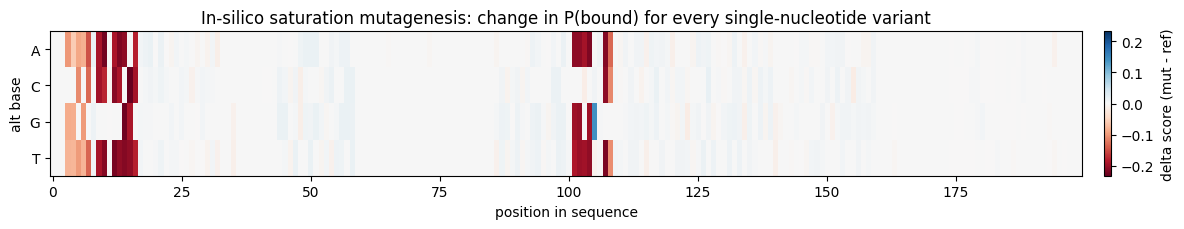

In [10]:
vlim = max(abs(delta).max(), 1e-6)
plt.figure(figsize=(12, 2.4))
im = plt.imshow(delta, aspect="auto", cmap="RdBu", vmin=-vlim, vmax=vlim)
plt.yticks(range(4), list(BASES))
plt.xlabel("position in sequence"); plt.ylabel("alt base")
plt.title("In-silico saturation mutagenesis: change in P(bound) for every single-nucleotide variant")
plt.colorbar(im, fraction=0.025, pad=0.02, label="delta score (mut - ref)")
plt.tight_layout(); plt.show()

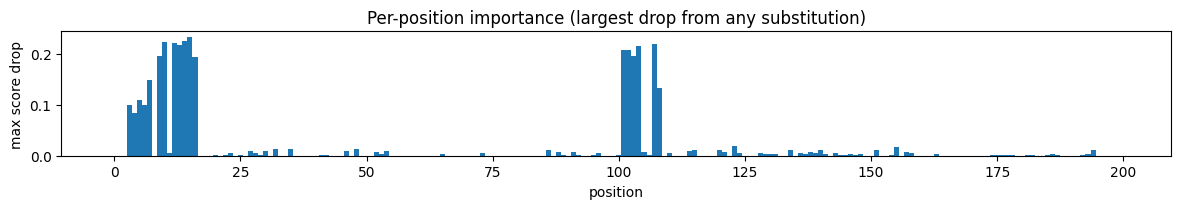

most important position: 15
The important positions cluster into a short contiguous stretch -- the model localised
the planted CTCF-like motif on its own, without ever being told where it was.


In [11]:
# per-position importance = the biggest score drop achievable at that position
importance = -delta.min(axis=0)
plt.figure(figsize=(12, 2.2))
plt.bar(range(len(importance)), importance, width=1.0)
plt.xlabel("position"); plt.ylabel("max score drop")
plt.title("Per-position importance (largest drop from any substitution)")
plt.tight_layout(); plt.show()

peak = int(importance.argmax())
print(f"most important position: {peak}")
print("The important positions cluster into a short contiguous stretch -- the model localised")
print("the planted CTCF-like motif on its own, without ever being told where it was.")

## 6b. Rank the variants

Every `(position, alternative base)` pair is a candidate single-nucleotide variant. Sorting by
effect size gives a **prioritized variant list** — the deliverable the whole team is after.

In [12]:
ref_idx = example_1hot.argmax(0)   # reference base at each position
records = []
for j in range(len(example_seq)):
    for b in range(4):
        if b == ref_idx[j]:
            continue                # skip the reference allele
        records.append({"position": j,
                        "ref": BASES[ref_idx[j]],
                        "alt": BASES[b],
                        "delta_score": float(delta[b, j])})
variants = pd.DataFrame(records)
variants["abs_effect"] = variants["delta_score"].abs()
variants = variants.sort_values("abs_effect", ascending=False).reset_index(drop=True)
print("Top 10 highest-impact single-nucleotide variants (by |delta score|):")
variants.head(10)

Top 10 highest-impact single-nucleotide variants (by |delta score|):


,position,ref,alt,delta_score,abs_effect
0,15,A,C,-0.232504,0.232504
1,14,C,G,-0.226132,0.226132
2,10,G,A,-0.223426,0.223426
3,12,G,T,-0.220486,0.220486
4,107,G,T,-0.218485,0.218485
5,13,G,A,-0.216855,0.216855
6,104,C,A,-0.216160,0.216160
7,10,G,T,-0.214115,0.214115
8,14,C,T,-0.213819,0.213819
9,107,G,A,-0.213676,0.213676


## 7. How this connects to Akita and the team goal

| This demo | Akita (Paper #4) |
|---|---|
| Input: ~200 bp one-hot DNA | Input: 1 Mb (2^20 bp) one-hot DNA |
| CNN -> single binding probability | Deep CNN -> full Hi-C contact map |
| ISM effect = change in P(bound) | ISM / variant effect = change in 3D folding |
| Ranks single-nucleotide variants | Ranks structural variants, eQTLs |

The **workflow is identical** — one-hot encode, predict with a CNN, interpret by mutagenesis,
rank variants by predicted effect. The review (Paper #5) is the conceptual map; Akita is one
concrete, state-of-the-art instance of it aimed at 3D genome folding. See
[`../04-akita/`](../04-akita/) for the inference notebook that runs the real Akita model.

**Takeaway for variant prioritization:** a sequence-to-function model plus saturation
mutagenesis turns "which of these variants matters?" into a scored, ranked list — no wet-lab
assay required for the first pass.

## References

- Eraslan, Avsec, Gagneur & Theis. *Deep learning: new computational modelling techniques for genomics.* **Nat Rev Genet** 20, 389-403 (2019).
- Fudenberg, Kelley & Pollard. *Predicting 3D genome folding from DNA sequence with Akita.* **Nat Methods** 17, 1111-1117 (2020).
- Alipanahi et al. *Predicting the sequence specificities of DNA- and RNA-binding proteins by deep learning (DeepBind).* **Nat Biotechnol** (2015).
- Kelley et al. *Basset / Basenji* — sequential CNNs for regulatory genomics (2016, 2018).

*Notebook by Aditya — Team 1, Variant Prioritization. Synthetic data; runs end-to-end on CPU.*